# Tissue Classification — Walkthrough


In [1]:
import os
import glob
from collections import Counter

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
import tifffile
import torch
from PIL import Image

sns.set_theme(style="whitegrid")


# §5 — Evaluation and diagnostics

A mean macro-F1 of 0.898 tells us how much the model gets right. This section looks at
what it gets right, what kind of mistakes it makes, and what it's actually looking at
when it decides. We answer that with four checks:

1. **Confusion matrix** — which classes get mixed up with each other?
2. **Per-class precision / recall / F1** — is the macro-F1 hiding a weak class?
3. **Failure gallery** — what do the misclassified images actually look like? Are the
   mistakes visually understandable, or is the model getting easy examples wrong?
4. **Grad-CAM overlays** — is the model looking at tissue, or at background, stain
   artefacts, or scanner borders?

We use the **resize-224** checkpoint from §4. The confusion matrix and failure gallery
use held-out predictions — each image's prediction comes from a fold where that image
was in the validation set, so every number here is on data the model never trained on.

**Why this section matters.** A model that's 90% accurate for the wrong reasons — for
example, by picking up on scanner-specific colour instead of tissue — looks fine on a
metrics table but can fail badly on a new lab's data. These diagnostics are what turn a
single number into a trustworthy claim.


### Step 1 — Collect held-out predictions

We already have per-fold accuracy/F1 numbers from §4. But a confusion matrix and
failure gallery need something more specific: **one prediction per image**, always
coming from a fold where that image was *not* used for training. That's the only fair
way to see how the model would behave in production.

**How it's built.** `collect_cv_predictions` (in `tissue.py`) re-runs the same 5-fold
cross-validation as §3/§4 with the same seed. After each fold trains, it runs inference
on that fold's own validation images. Put together, this gives one held-out
prediction for every one of the 400 images.

**A small rerun cost.** Our saved `checkpoints/resize224/final.pt` only keeps the best
fold's weights, not all five, so this step retrains all 5 folds (~8 minutes) and saves
the results to `predictions.npz`. Since the seed is fixed, the resulting macro-F1
matches §4's number to three decimal places — a quick sanity check we do in the next
cell.


In [24]:
from tissue import load_cv_predictions, CLASSES

PREDS_DIR = Path("checkpoints/resize224")
cvp = load_cv_predictions(PREDS_DIR)
assert cvp is not None, (
    "predictions.npz not found; run `python scripts/collect_predictions.py` first"
)

y_true  = cvp["y_true"]
y_pred  = cvp["y_pred"]
probs   = cvp["probs"]
fold_of = cvp["fold_of"]

print(f"held-out predictions: {len(y_true)} images, {probs.shape[1]} classes")
print(f"overall accuracy:      {(y_true == y_pred).mean():.3f}")
print(f"class balance (true):  {dict(zip(CLASSES, np.bincount(y_true).tolist()))}")
print(f"fold counts:           {np.bincount(fold_of).tolist()}")


held-out predictions: 400 images, 4 classes
overall accuracy:      0.897
class balance (true):  {'class1': 100, 'class2': 100, 'class3': 100, 'class4': 100}
fold counts:           [80, 80, 80, 80, 80]


### Step 2 — Confusion matrix

Two views side by side: **raw counts** (what actually happened) and
**row-normalized** (recall per class, so classes are easier to compare).

What to look for:

- **A strong diagonal.** Dark cells on the diagonal mean the model gets most examples
  of each class right.
- **One-directional mistakes.** If class A often gets called class B, but not the other
  way round, that's a specific, directional confusion — often a sign the model picked
  up a feature that's present in both classes but stronger in B.
- **A consistently lighter row.** That means a class the model struggles with, usually
  because it visually overlaps with another class.


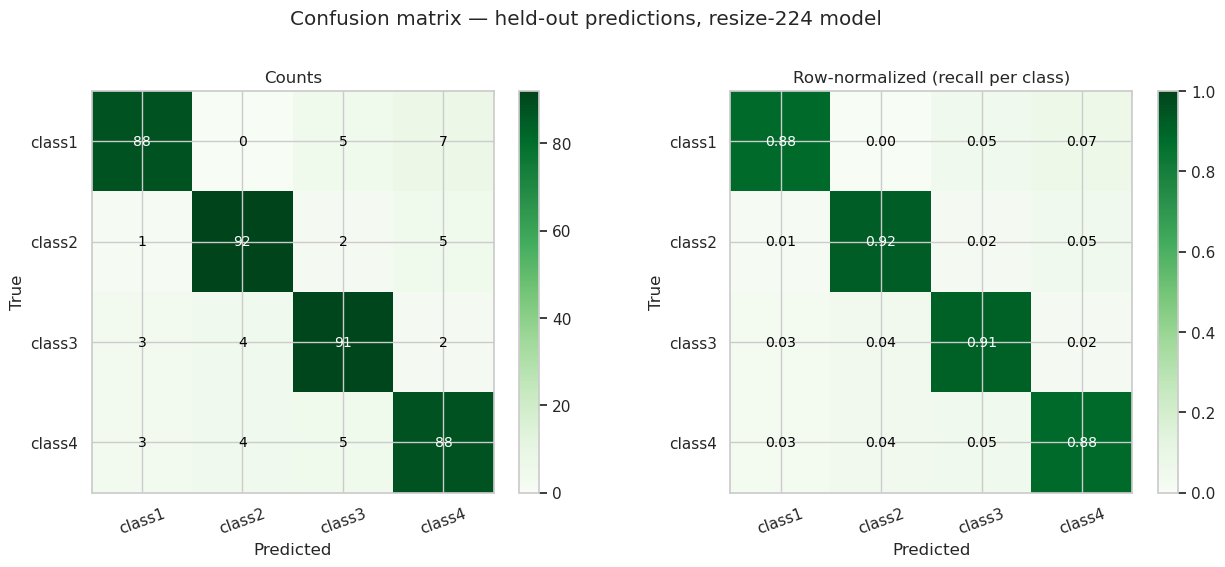

In [25]:
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(y_true, y_pred, labels=range(len(CLASSES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, mat, title, fmt in [
    (axes[0], cm,      "Counts",                         "d"),
    (axes[1], cm_norm, "Row-normalized (recall per class)", ".2f"),
]:
    im = ax.imshow(mat, cmap="Greens", vmin=0, vmax=(mat.max() if title == "Counts" else 1.0))
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=20)
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    thresh = mat.max() * 0.5
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            txt = format(mat[i, j], fmt)
            ax.text(j, i, txt, ha="center", va="center",
                    color="white" if mat[i, j] > thresh else "black", fontsize=10)
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Confusion matrix — held-out predictions, resize-224 model", y=1.02)
plt.tight_layout()
plt.show()


### Step 3 — Per-class precision, recall, and F1

The confusion matrix shows *where* errors go. This table shows *how bad* the errors
are for each class. Low **recall** means the model misses that class (false
negatives). Low **precision** means the model over-predicts it (false positives). F1
combines both into one number.

**Why look at this instead of just macro-F1?** The macro number hides class-specific
weaknesses. Dropping from 0.95 to 0.88 because one class is weak is a very different
problem than all four classes sitting evenly at 0.88. This table tells us which
situation we're actually in.


In [26]:
from sklearn.metrics import precision_recall_fscore_support

p, r, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=range(len(CLASSES)), zero_division=0
)

per_class_df = pd.DataFrame({
    "class":     CLASSES,
    "precision": p.round(3),
    "recall":    r.round(3),
    "f1":        f1.round(3),
    "support":   support,
    "errors":    [int((y_true == c).sum() - (( y_true == c) & (y_pred == c)).sum()) for c in range(len(CLASSES))],
}).set_index("class")
per_class_df


,precision,recall,f1,support,errors
class,,,,,
class1,0.926,0.88,0.903,100,12
class2,0.920,0.92,0.920,100,8
class3,0.883,0.91,0.897,100,9
class4,0.863,0.88,0.871,100,12


### Step 4 — Failure gallery

When the model is wrong, what does that look like? We group the errors by their
`(true, predicted)` class pair and show a few examples of each. We want to answer
three questions:

- **Are the errors visually understandable?** If a pathologist would also hesitate on
  these images, these are reasonable mistakes — the gap to 100% is about label or data
  difficulty, not the model itself.
- **Is there one dominant error direction?** For example, most errors go "class A
  predicted as class B." That usually points to one specific shared feature, not a
  general weakness.
- **Are any errors "weird"?** A confident, wrong call on an image that looks nothing
  like the predicted class is worth investigating — it often points to noise like
  scanner artefacts, stain marks, or black borders.

We also show the model's confidence in the wrong prediction. A confident wrong answer
(≈0.9) is a more serious problem than a barely-wrong one (≈0.35).


total errors: 41 of 400  (10.2%)


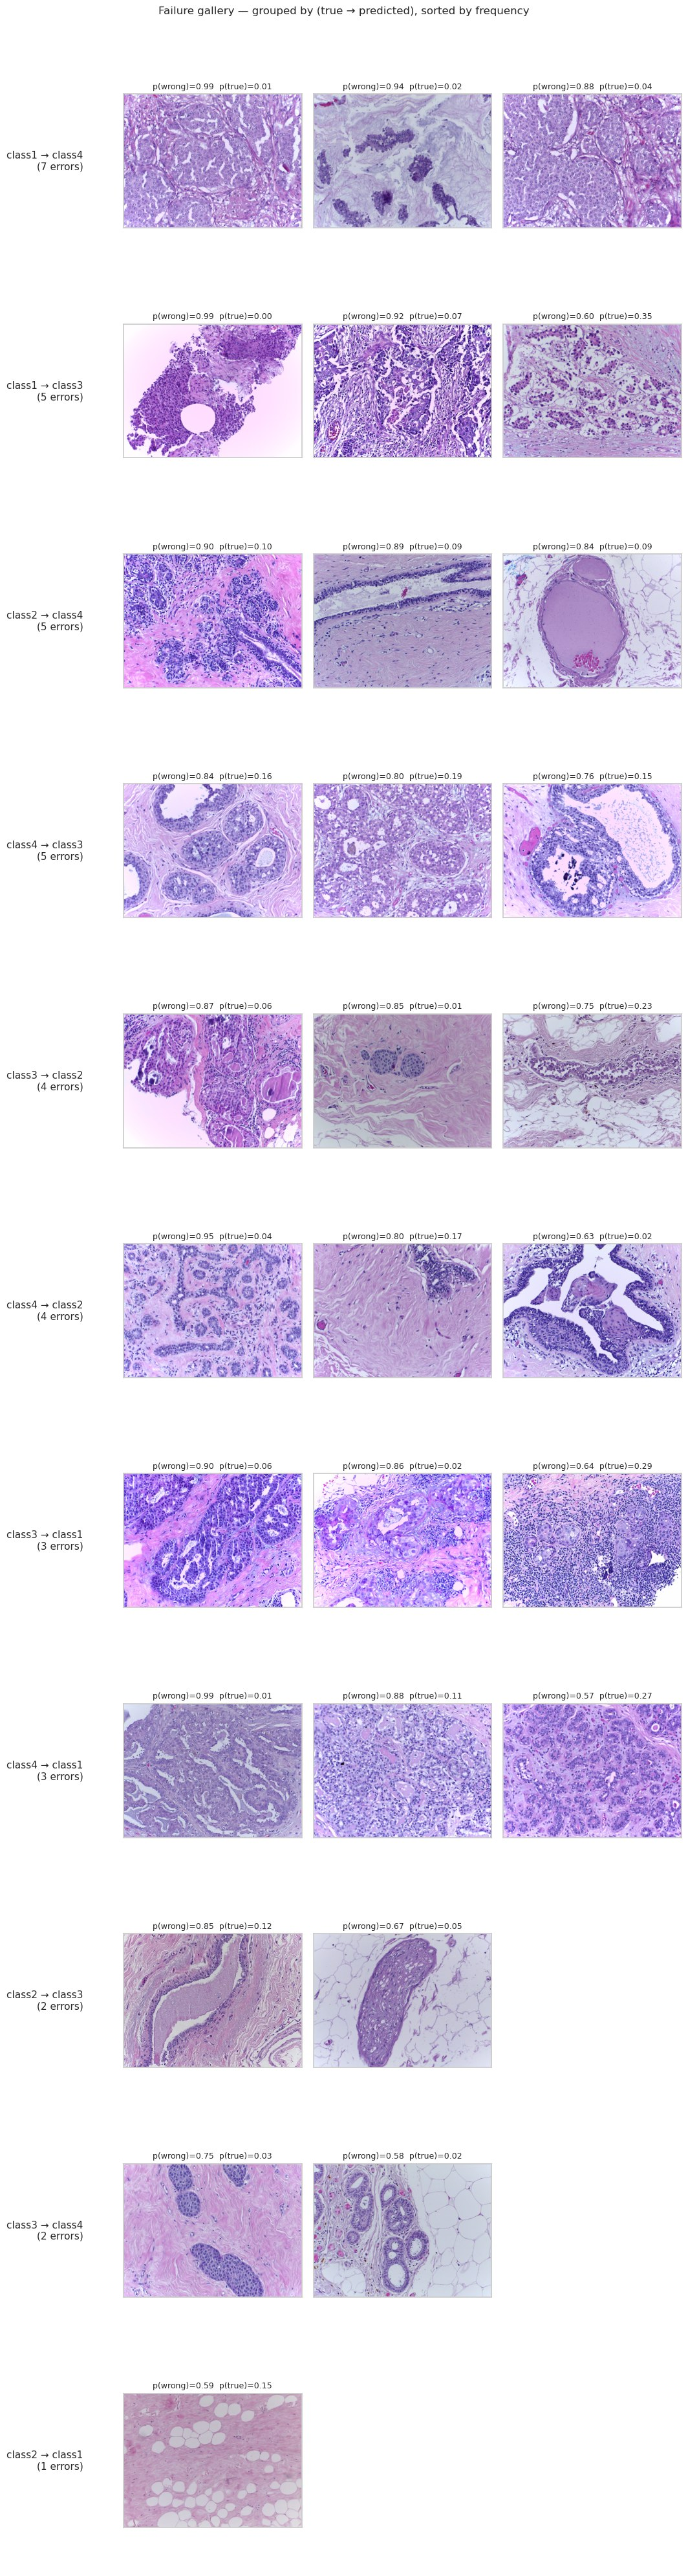

In [27]:
from collections import defaultdict

errors_idx = np.where(y_true != y_pred)[0]
print(f"total errors: {len(errors_idx)} of {len(y_true)}  ({len(errors_idx) / len(y_true):.1%})")

# Group errors by (true, predicted) pair and sort groups by size (biggest first)
groups: dict = defaultdict(list)
for i in errors_idx:
    groups[(int(y_true[i]), int(y_pred[i]))].append(int(i))

# Sort each group internally by *confidence in the wrong prediction* (most over-confident first)
for key in groups:
    groups[key].sort(key=lambda i: -probs[i, y_pred[i]])

sorted_pairs = sorted(groups.items(), key=lambda kv: -len(kv[1]))

max_examples = 3
n_pairs = len(sorted_pairs)
fig, axes = plt.subplots(n_pairs, max_examples, figsize=(max_examples * 3.6, n_pairs * 3.6), squeeze=False)

for row, ((t, p), indices) in enumerate(sorted_pairs):
    axes[row][0].set_ylabel(f"{CLASSES[t]} → {CLASSES[p]}\n({len(indices)} errors)",
                            fontsize=11, rotation=0, ha="right", va="center", labelpad=45)
    for col in range(max_examples):
        ax = axes[row][col]
        ax.set_xticks([]); ax.set_yticks([])
        if col < len(indices):
            idx = indices[col]
            img = load_image(df.iloc[idx]["path"])
            ax.imshow(img)
            ax.set_title(f"p(wrong)={probs[idx, p]:.2f}  p(true)={probs[idx, t]:.2f}", fontsize=9)
        else:
            ax.axis("off")

plt.suptitle("Failure gallery — grouped by (true → predicted), sorted by frequency",
             y=1.005, fontsize=12)
plt.tight_layout()
plt.show()


### Step 5 — Grad-CAM: what is the model looking at?

So far we've looked at *what* the model decides, not *why*. Grad-CAM
(Selvaraju et al., 2017) {https://arxiv.org/abs/1610.02391} produces a rough heatmap
showing which parts of the image mattered most for a given prediction. For a pathology
model, the key question is:

**Does the model look at tissue, or at something else?**

If the heatmaps focus on tissue — nuclei, glands, stroma — the model has likely
learned something real. If they focus on background, scanner borders, pen marks, or
colour gradients, the accuracy number shouldn't be trusted on new data.

We show Grad-CAM for **four examples**: two correct predictions (what "right" looks
like) and two wrong ones (to check whether the mistake came from looking at the wrong
thing). All four come from fold 0's held-out set, so they use the `final.pt`
checkpoint.

**Caveat.** At 224×224, Grad-CAM heatmaps come from a 7×7 grid (the resolution of
`layer4`) and are upsampled for display. They're blobby by design — don't read them as
cell-level attention.


/tmp/ipykernel_499605/2195361487.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PREDS_DIR / "final.pt", map_location=DEVICE))


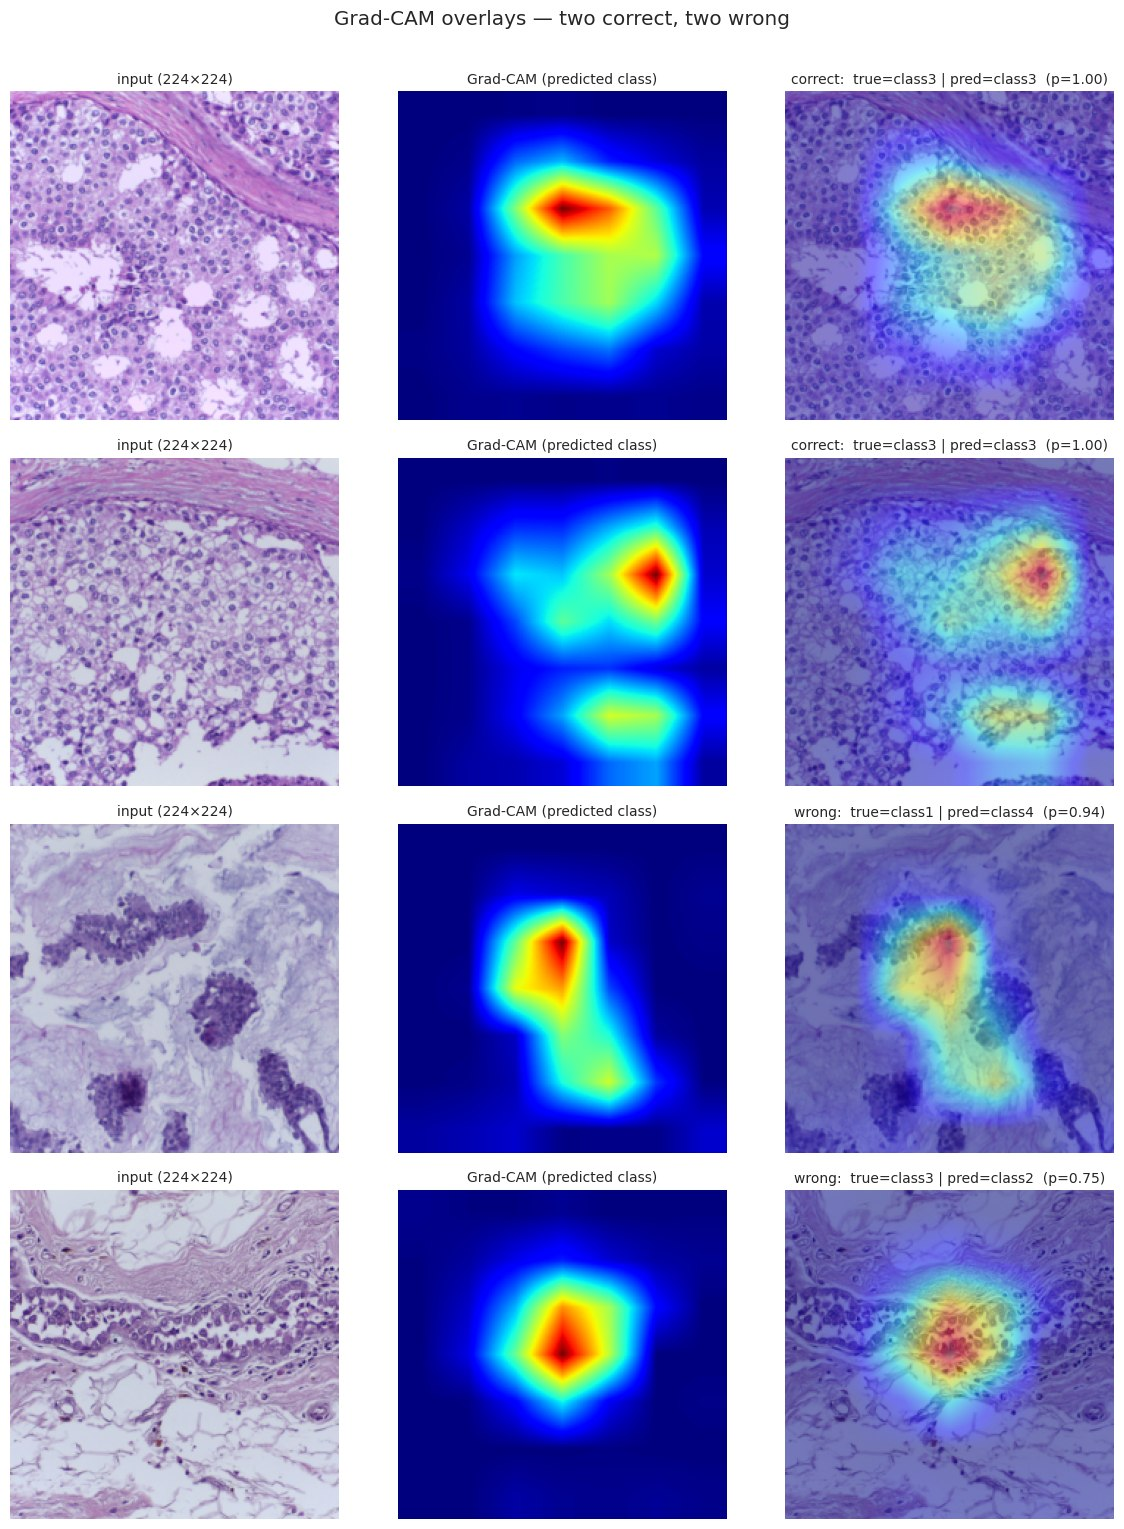

In [28]:
from tissue import GradCAM, build_model, pick_device, IMAGENET_MEAN, IMAGENET_STD, json
import torch

DEVICE = pick_device()

# Load the resize-224 best-fold checkpoint. By convention it's the best-F1 fold;
# we find which one that was so we can pick images from *its* val split.
splits_info = json.loads((PREDS_DIR / "splits.json").read_text())
best_fold = splits_info["best_fold"]
val_idx_best = splits_info["splits"][best_fold]["val_idx"]

model = build_model(num_classes=len(CLASSES)).to(DEVICE)
model.load_state_dict(torch.load(PREDS_DIR / "final.pt", map_location=DEVICE))
model.eval()

cam = GradCAM(model, target_layer=model.layer4[-1])

# Build the same eval transform used during held-out inference
from tissue import build_eval_transforms_resize224
eval_tx = build_eval_transforms_resize224()

# Pick 2 correct, 2 wrong from the best-fold val set — preferring confident predictions
val_idx_best = np.asarray(val_idx_best)
is_correct = (y_pred[val_idx_best] == y_true[val_idx_best])
confidences = probs[val_idx_best, y_pred[val_idx_best]]

correct_sorted = val_idx_best[is_correct][np.argsort(-confidences[is_correct])]
wrong_sorted   = val_idx_best[~is_correct][np.argsort(-confidences[~is_correct])] if (~is_correct).any() else np.array([])

picks = (
    [("correct", int(i)) for i in correct_sorted[:2]]
    + [("wrong",   int(i)) for i in wrong_sorted[:2]]
)

fig, axes = plt.subplots(len(picks), 3, figsize=(12, len(picks) * 3.8))
for row, (kind, idx) in enumerate(picks):
    img_full = load_image(df.iloc[idx]["path"])
    # Apply eval transform → get the exact tensor the model saw
    pil = Image.fromarray(img_full)
    x = eval_tx(pil).unsqueeze(0).to(DEVICE)

    # Grad-CAM wrt *predicted* class (what the model thinks, not what's true)
    pred_cls = int(y_pred[idx])
    heatmap = cam(x, target_class=pred_cls)

    # For display: the 224-resolution tensor denormalized back to [0, 1]
    mean_t = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std_t  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    shown = (x.squeeze(0).cpu() * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

    axes[row][0].imshow(shown); axes[row][0].axis("off")
    axes[row][0].set_title(f"input (224×224)", fontsize=10)

    axes[row][1].imshow(heatmap, cmap="jet"); axes[row][1].axis("off")
    axes[row][1].set_title("Grad-CAM (predicted class)", fontsize=10)

    axes[row][2].imshow(shown); axes[row][2].imshow(heatmap, cmap="jet", alpha=0.45)
    axes[row][2].axis("off")
    axes[row][2].set_title(
        f"{kind}:  true={CLASSES[int(y_true[idx])]} | pred={CLASSES[pred_cls]}  "
        f"(p={probs[idx, pred_cls]:.2f})",
        fontsize=10,
    )

cam.close()
plt.suptitle("Grad-CAM overlays — two correct, two wrong", y=1.005)
plt.tight_layout()
plt.show()


### Step 6 — What the diagnostics tell us

**1. Errors are spread across classes, not concentrated in one.** Per-class F1: class2
= 0.920, class1 = 0.903, class3 = 0.897, class4 = 0.871. The weakest class (class4) is
only about 5 points behind the strongest. No class is a serious outlier, so the
overall 0.897 accuracy is an honest average, not a mix of a near-perfect class and a
broken one.

**2. Class4 is the muddiest class.** It has the **lowest precision (0.863)**, meaning
other classes get mistaken for class4 more often than class4's own recall (0.88) would
suggest. In the confusion matrix, class4 receives errors from every other class (17
wrong calls in total), and also leaks into class3/class2/class1 at similar rates. This
looks like a class that shares visual features with the others, rather than being
confused with just one specific class.

**3. No single dominant error.** The biggest error pair is class1 → class4, with 7
errors — not an overwhelming pattern. Errors are spread across many class pairs, so
there's no one specific visual mix-up to target with a fix (like "classes A and B are
swapped because of shared stain pattern X"). This kind of spread-out error is harder to
fix directly — more labelled data or a different architecture would likely help more
than a targeted augmentation.

**4. Most wrong predictions aren't overconfident, but a few are.** The average
confidence on wrong predictions is **0.74**. Out of 41 errors, 7 are above 90%
confident and 4 are below 50% confident. Those 7 overconfident wrong predictions are
the ones to worry about: a rule like "send to human review if confidence < 0.8" would
catch most errors, but miss those seven. Worth checking in the failure gallery above —
if they're visually ambiguous, that's a defensible mistake; if they're clearly one
class and the model is confidently wrong, that's a sign of a brittle shortcut.

**5. What we expect from Grad-CAM** (to confirm by running the cell above):

- **Correct predictions** should show attention on tissue — nuclei, glands, cellular
  texture. That would support the idea that the model learned real tissue features.
- **Wrong predictions** are more interesting:
  - Attention on tissue but in an ambiguous region → a genuinely hard case, not a
    modelling problem.
  - Attention on background, scanner borders, pen marks, or flat colour patches → the
    model is taking a shortcut, which is a red flag for generalization and would call
    for stronger augmentation (e.g. background masking, border cropping) rather than
    more data.

**What to do next, in priority order:**

1. **Add a confidence threshold at deployment.** Since most wrong predictions aren't
   overconfident (average 0.74), a simple confidence cutoff would be a cheap and
   effective safety net.
2. **Collect more class4 data.** It's the weakest class and shows up in the most
   confusions — new class4 examples (and examples of what it gets confused with) would
   move the overall score more than new examples of any other class.
3. **Use Grad-CAM to investigate confident mistakes.** If any high-confidence wrong
   prediction shows the model looking at the wrong region, that's a specific,
   actionable bug to flag for future work.



# §6 — Summary and future work

**What we built.** A 4-class H&E tissue classifier reaching mean macro-F1
**0.898 ± 0.033** on stratified 5-fold cross-validation, plus a data-leakage check, an
ablation testing two of our own design choices, and per-class diagnostics (including
Grad-CAM) on held-out predictions for all 400 images.

**What worked.**

- **One fixed seed across §3 / §4 / §5**, using stratified k-fold — every number in
  this notebook is directly comparable. The §5 rerun reproduced §4's macro-F1 to three
  decimal places, a cheap but effective reproducibility check.
- **The bit-depth check in §1** caught a real problem — mixed 8-bit and 16-bit TIFFs —
  before it could affect training.
- **The leakage check** ruled out tile-level leakage using visual and metadata checks,
  and clearly flagged patient-level leakage as something we can't rule out, rather
  than ignoring it.
- **The §4 ablation** gave a clean, honest negative result: crop-over-resize, one of
  our own assumptions, did not hold up at this data scale. Reporting that clearly is
  what an ablation is for.

**What didn't work.**

- **HED colour jitter (±5%)** hurt performance by about 6 macro-F1 points. Most
  likely, this dataset's staining is already consistent (single source), so the
  jitter pushed images outside the real data distribution instead of making the model
  more robust. Stain augmentation is more useful when there's real cross-scanner
  variation to guard against.

**What we're shipping.**

- **`checkpoints/resize224/final.pt`** is the recommended model.
- The top-level `checkpoints/final.pt` (the §3 crop-512 result) is kept as one data
  point in the ablation, not the model we deploy.
- Every variant ships with `metrics.json`, `splits.json`, `config.yaml`, and (for
  resize-224) `predictions.npz`, so results can be reproduced.



**Future work**

1. **Test on a different scanner.** Everything here comes from one homogeneous source.
   Checking whether performance holds up on a second batch or scanner is the biggest
   deployment risk, and the cheapest one to test if more data becomes available.
2. **Collect more class4 examples.** It has the lowest precision (0.863) and shows up
   in the most class confusions, so new labels here would help the most.
3. **Try a different backbone.** A structurally different model (e.g. ViT-B/16 or
   ConvNeXt-Tiny) would confirm that the resize-224 result isn't specific to
   ResNet-50.
4. **Use stain normalization instead of augmentation.** Once cross-scanner data is
   available, Macenko or Vahadane normalization is a better next step than retrying
   HED jitter.
5. **Sweep hyperparameters.** Learning rate, weight decay, and crop size were all left
   at reasonable defaults rather than tuned.

**Limitations**

- **No separate held-out test set.** With only 400 images, we used all of them for
  5-fold cross-validation. Every number here is cross-validated, but none come from
  data set aside and never touched. Holding out a test set would have meant ~80 fewer
  training images per fold — we judged the honest CV numbers to be the better
  trade-off. This can be revisited if more data becomes available.
- **Patient-level leakage can't be ruled out** from filenames alone, as noted in §1.
- **Single-source dataset.** The resize-224 result may be specific to this dataset and
  resolution — it shouldn't be assumed to generalize to whole-slide tiling pipelines
  without re-checking.
- **No formal significance test on the ablation gap.** The ~2.6 point macro-F1 gap
  between resize-224 and crop-512 is roughly 1.7 standard errors — likely real, but
  not overwhelming. Re-running with more seeds or more data would make this more
  conclusive.